Đã tải thành công dataset với 10000 dòng và 26 cột.
Kích thước ban đầu: (10000, 26)
Đang xử lý ngôn ngữ tự nhiên (NLP) cho review, vui lòng đợi...
Kích thước sau khi làm sạch: (10000, 28)


C:\Users\Pangorin\AppData\Local\Temp\ipykernel_3352\3490782038.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='reviews.rating', ax=axes[0], palette='viridis')


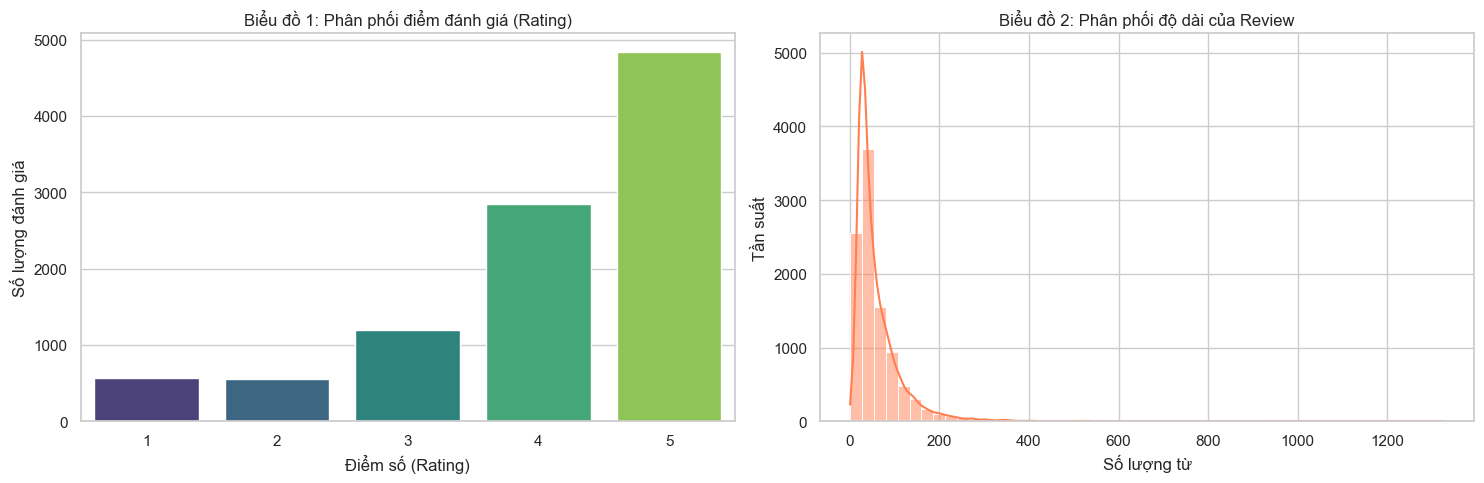

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# 1. Ép Jupyter chuyển thư mục làm việc ra ngoài gốc dự án
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Thêm thư mục gốc vào hệ thống để Python hiểu được thư mục src/
sys.path.append(os.getcwd())

from src.data.loader import load_raw_data
from src.data.cleaner import preprocess_dataframe

# 2. Đọc dữ liệu (Chú ý: config_path không còn '../' nữa vì ta đã ở thư mục gốc)
df_raw = load_raw_data(config_path="configs/params.yaml")

# 3. Chạy hàm dọn dẹp NLP
df_clean = preprocess_dataframe(df_raw, text_col='reviews.text', rating_col='reviews.rating')

# 2. Vẽ 2 biểu đồ phân phối
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ 1: Phân phối điểm đánh giá
sns.countplot(data=df_clean, x='reviews.rating', ax=axes[0], palette='viridis')
axes[0].set_title('Biểu đồ 1: Phân phối điểm đánh giá (Rating)')
axes[0].set_xlabel('Điểm số (Rating)')
axes[0].set_ylabel('Số lượng đánh giá')

# Biểu đồ 2: Phân phối độ dài đánh giá
sns.histplot(data=df_clean, x='Review_Length', bins=50, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Biểu đồ 2: Phân phối độ dài của Review')
axes[1].set_xlabel('Số lượng từ')
axes[1].set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

C:\Users\Pangorin\AppData\Local\Temp\ipykernel_3352\2570720919.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_words, x='Count', y='Word', palette='magma')


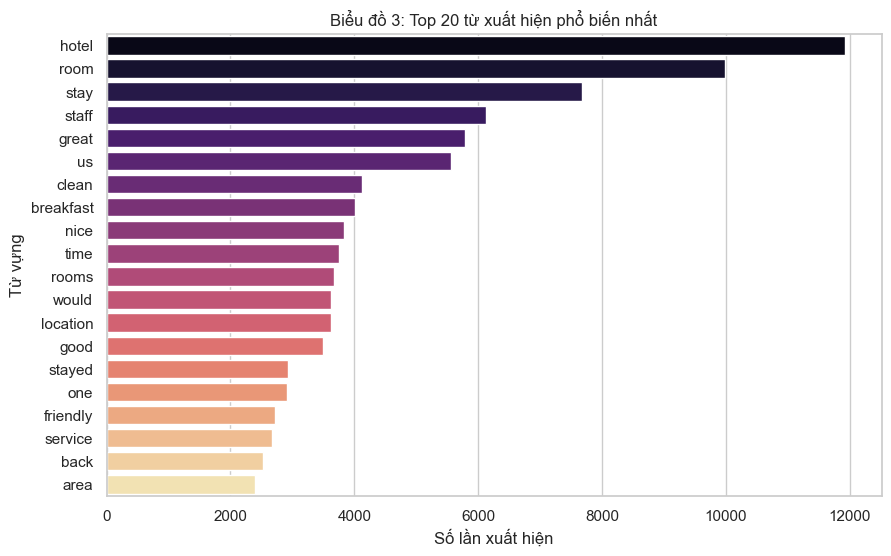

Đã lưu dữ liệu sạch tại: data/processed/cleaned_reviews.csv


In [2]:
from collections import Counter
import os

# Phân tích top từ vựng xuất hiện nhiều nhất
all_words = " ".join(df_clean['Cleaned_Review']).split()
word_counts = Counter(all_words)
df_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=df_words, x='Count', y='Word', palette='magma')
plt.title('Biểu đồ 3: Top 20 từ xuất hiện phổ biến nhất')
plt.xlabel('Số lần xuất hiện')
plt.ylabel('Từ vựng')
plt.show()

# Đảm bảo thư mục tồn tại (tránh lỗi ngớ ngẩn)
output_dir = "data/processed"
os.makedirs(output_dir, exist_ok=True)

# Lưu lại data đã dọn dẹp (đã bỏ '../' ở đầu đường dẫn)
output_path = f"{output_dir}/cleaned_reviews.csv"
df_clean.to_csv(output_path, index=False)
print(f"Đã lưu dữ liệu sạch tại: {output_path}")